# Energy Consumption Forecasting System Using Machine Learning and Time Series Analysis

### A Multivariate Time-Series Approach with Weather Integration

## 1. Introduction

Electricity demand forecasting plays a crucial role in grid stability, energy planning,
and operational efficiency. Accurate short-term and medium-term forecasts enable
better load balancing, cost optimization, and policy-level decisions.

This project develops a multivariate time-series forecasting system that integrates
historical electricity consumption with exogenous weather variables.

The study compares classical time-series methods and machine learning models to
evaluate their effectiveness in capturing temporal and nonlinear patterns in energy demand.

## 2. Problem Statement

The objective is to forecast hourly electricity consumption using:

- Historical load values
- Seasonal time components
- Weather variables (temperature)

The goal is to evaluate:
1. Whether classical time-series models are sufficient.
2. Whether machine learning models better capture nonlinear dependencies.

## 3. Dataset Description

In [2]:
#3.1 Importing Libraries

import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_theme()

In [3]:
#3.2 Load PJM Dataset

# Load PJM dataset
pjm = pd.read_csv("PJMW_hourly.csv")

# Convert datetime
pjm["Datetime"] = pd.to_datetime(pjm["Datetime"])

# Set index
pjm = pjm.set_index("Datetime")

# Rename column for clarity
pjm = pjm.rename(columns={"PJMW_MW": "Load_MW"})

# Basic inspection
print("PJM Shape:", pjm.shape)
print("\nTime Range:")
print(pjm.index.min(), "to", pjm.index.max())

pjm.head()

PJM Shape: (143206, 1)

Time Range:
2002-04-01 01:00:00 to 2018-08-03 00:00:00


,Load_MW
Datetime,
2002-12-31 01:00:00,5077.0
2002-12-31 02:00:00,4939.0
2002-12-31 03:00:00,4885.0
2002-12-31 04:00:00,4857.0
2002-12-31 05:00:00,4930.0


In [4]:
#3.3 Load Temperature Dataset

# Load temperature dataset
temp = pd.read_csv("temperature.csv")

# Convert datetime
temp["datetime"] = pd.to_datetime(temp["datetime"])

# Set index
temp = temp.set_index("datetime")

# Keep only Philadelphia temperature
temp = temp[["Philadelphia"]]

# Convert Kelvin to Celsius
temp["Temperature_C"] = temp["Philadelphia"] - 273.15

# Drop original Kelvin column
temp = temp.drop(columns=["Philadelphia"])

# Basic inspection
print("Temperature Shape:", temp.shape)
print("\nTime Range:")
print(temp.index.min(), "to", temp.index.max())

temp.head()

Temperature Shape: (45253, 1)

Time Range:
2012-10-01 12:00:00 to 2017-11-30 00:00:00


,Temperature_C
datetime,
2012-10-01 12:00:00,NaN
2012-10-01 13:00:00,12.480000
2012-10-01 14:00:00,12.513208
2012-10-01 15:00:00,12.606824
2012-10-01 16:00:00,12.700440


In [5]:
#3.4 Restrict to Overlapping Period

# Find overlapping time window
start_date = max(pjm.index.min(), temp.index.min())
end_date = min(pjm.index.max(), temp.index.max())

print("Overlapping Period:")
print(start_date, "to", end_date)

# Filter both datasets
pjm = pjm[start_date:end_date]
temp = temp[start_date:end_date]

print("Filtered PJM shape:", pjm.shape)
print("Filtered Temp shape:", temp.shape)

Overlapping Period:
2012-10-01 12:00:00 to 2017-11-30 00:00:00
Filtered PJM shape: (42442, 1)
Filtered Temp shape: (45253, 1)


In [6]:
#3.5 Merge Datasets

# Merge on datetime index
data = pjm.merge(temp, left_index=True, right_index=True, how="inner")

print("Merged dataset shape:", data.shape)

data.head()

Merged dataset shape: (35099, 2)


,Load_MW,Temperature_C
Datetime,,
2012-10-01 12:00:00,5098.0,NaN
2012-10-01 13:00:00,5092.0,12.480000
2012-10-01 14:00:00,5103.0,12.513208
2012-10-01 15:00:00,5036.0,12.606824
2012-10-01 16:00:00,4985.0,12.700440


In [7]:
#3.6 Missing Values Check

print("Missing Values:\n")
print(data.isna().sum())

Missing Values:

Load_MW          0
Temperature_C    3
dtype: int64


In [8]:
data = data.dropna()

print("Final Shape After Cleaning:", data.shape)

Final Shape After Cleaning: (35096, 2)


In [9]:
data = data.sort_index()

In [10]:
print(data.index.is_monotonic_increasing)

True


In [11]:
data.head()

,Load_MW,Temperature_C
Datetime,,
2012-10-01 13:00:00,5092.0,12.480000
2012-10-01 14:00:00,5103.0,12.513208
2012-10-01 15:00:00,5036.0,12.606824
2012-10-01 16:00:00,4985.0,12.700440
2012-10-01 17:00:00,4975.0,12.794057


## 4 — Exploratory Data Analysis (EDA)

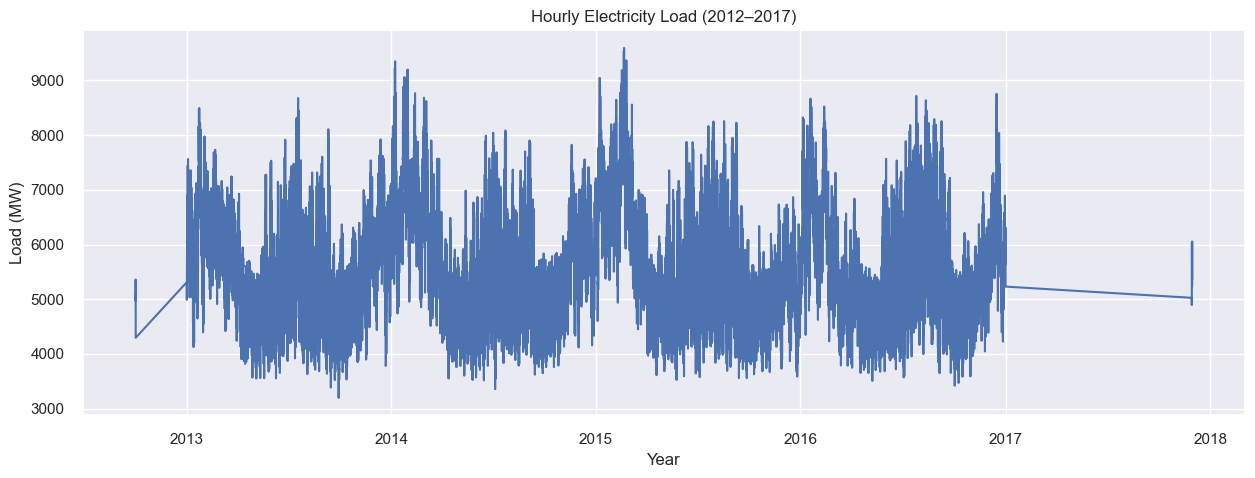

In [12]:
#4.1 Time-Series Visualization

plt.figure(figsize=(15,5))
plt.plot(data["Load_MW"])
plt.title("Hourly Electricity Load (2012–2017)")
plt.xlabel("Year")
plt.ylabel("Load (MW)")
plt.show()

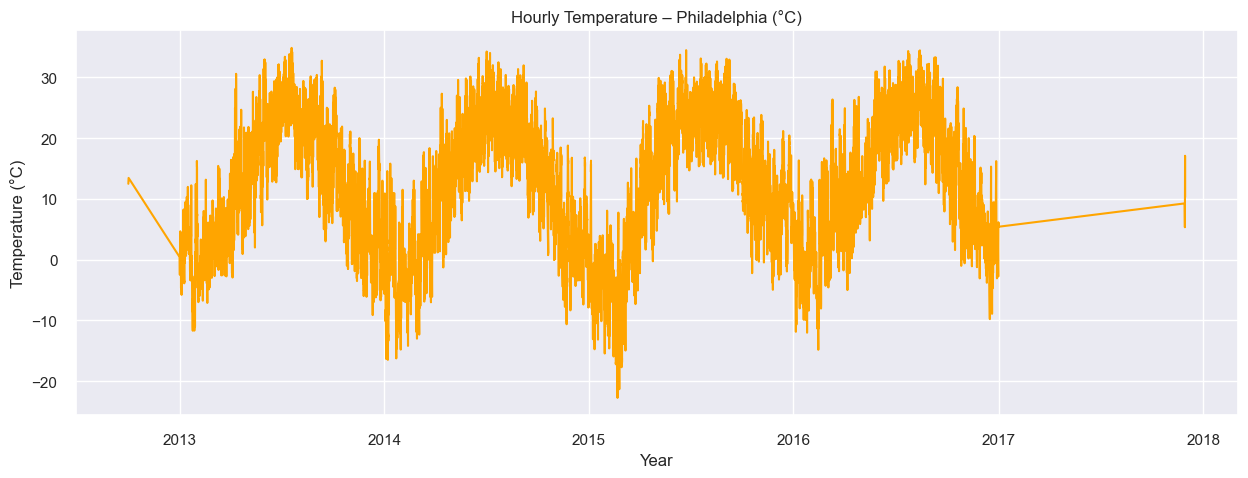

In [13]:
#4.2 Temperature Visualization

plt.figure(figsize=(15,5))
plt.plot(data["Temperature_C"], color="orange")
plt.title("Hourly Temperature – Philadelphia (°C)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

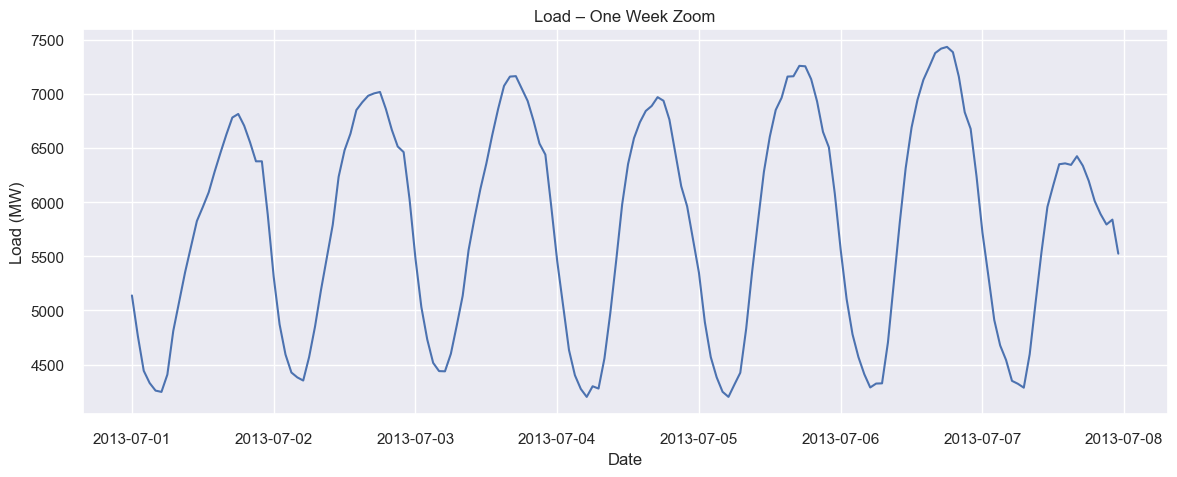

In [14]:
sample_week = data["2013-07-01":"2013-07-07"]

plt.figure(figsize=(14,5))
plt.plot(sample_week["Load_MW"])
plt.title("Load – One Week Zoom")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.show()

### Key Observations from Exploratory Analysis

The electricity load demonstrates clear annual seasonality, with recurring peaks during summer and winter months.

A pronounced daily (24-hour) cycle is visible in the weekly zoom, reflecting human activity patterns.

Temperature follows a strong yearly sinusoidal pattern and visually aligns with load fluctuations.

No major structural breaks or irregular anomalies are observed during the selected time horizon.

These patterns confirm the presence of both seasonal structure and weather dependency, motivating the use of time-series-aware and nonlinear modeling approaches.

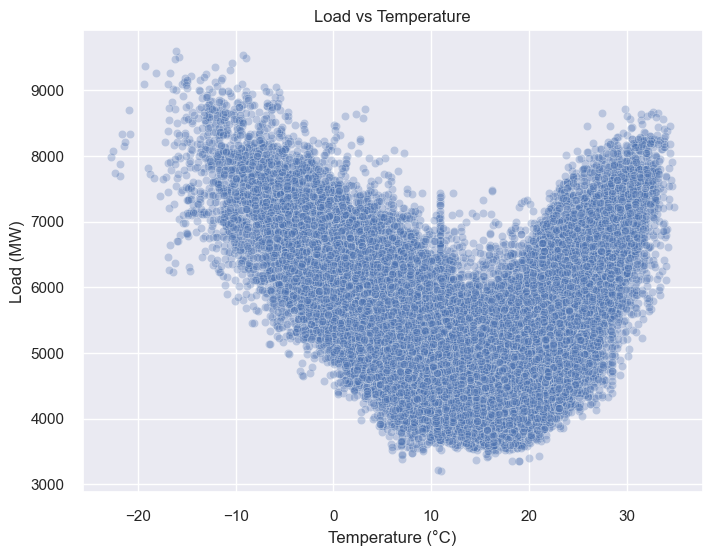

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data["Temperature_C"], y=data["Load_MW"], alpha=0.3)
plt.title("Load vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Load (MW)")
plt.show()

### Load–Temperature Relationship

The scatter plot reveals a nonlinear (U-shaped) relationship between temperature and electricity load. Demand increases during both low and high temperature extremes, likely due to heating and cooling requirements.

## 5. Time Series Decomposition

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

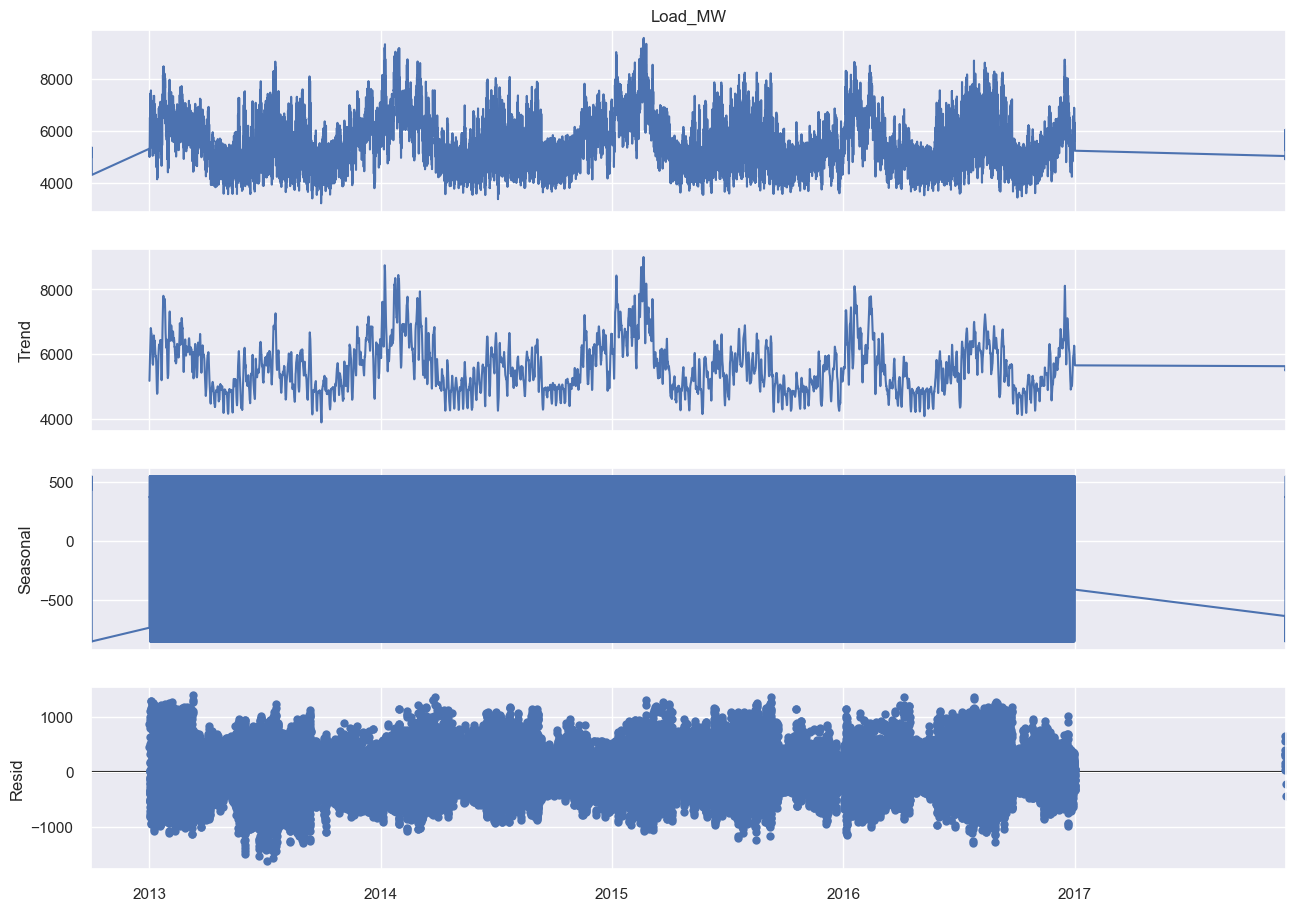

In [17]:
decomposition = seasonal_decompose(
    data["Load_MW"],
    model="additive",
    period=24
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

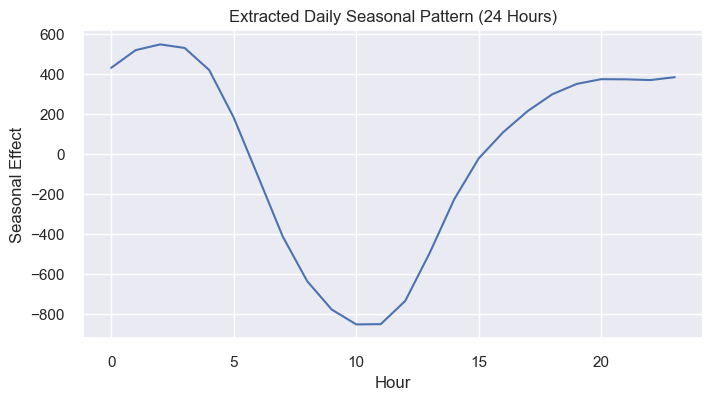

In [18]:
seasonal = decomposition.seasonal

one_day = seasonal[:24]

plt.figure(figsize=(8,4))
plt.plot(one_day.values)
plt.title("Extracted Daily Seasonal Pattern (24 Hours)")
plt.xlabel("Hour")
plt.ylabel("Seasonal Effect")
plt.show()

### Insights from Time Series Decomposition

The decomposition shows a strong and repeating daily pattern in electricity demand.

The trend changes slowly over time, with no sudden large shifts, which means the system is fairly stable.

The remaining residual values look random and centered around zero, indicating that most meaningful patterns are captured by the trend and seasonal components.

## 6. Feature Engineering

In [19]:
#6.1 – Create Time-Based Features 
# Extract calendar-based features to capture daily, weekly, and monthly seasonality

data_fe = data.copy()

data_fe["Hour"] = data_fe.index.hour
data_fe["DayOfWeek"] = data_fe.index.dayofweek
data_fe["Month"] = data_fe.index.month
data_fe["IsWeekend"] = data_fe["DayOfWeek"].isin([5,6]).astype(int)

In [20]:
#6.2 – Create Lag Features
# We are adding past values of load as predictors.

data_fe["Lag_1"] = data_fe["Load_MW"].shift(1)
data_fe["Lag_24"] = data_fe["Load_MW"].shift(24)
data_fe["Lag_168"] = data_fe["Load_MW"].shift(168)  # 7 days

In [21]:
#6.3 – Rolling Statistics
# Compute rolling mean to capture smoothed daily trend behavior

data_fe["Rolling_Mean_24"] = data_fe["Load_MW"].rolling(window=24).mean()

In [22]:
#6.4 – Nonlinear Temperature Effect
# Compute rolling mean to capture smoothed daily trend behavior

data_fe["Temp_Squared"] = data_fe["Temperature_C"] ** 2

In [23]:
#6.5 – Drop NA (Created by Shifting)
# Remove rows with missing values created by lag and rolling operations

data_fe = data_fe.dropna()

## 7. Time-Aware Train–Test Split

In [24]:
data

,Load_MW,Temperature_C
Datetime,,
2012-10-01 13:00:00,5092.0,12.480000
2012-10-01 14:00:00,5103.0,12.513208
2012-10-01 15:00:00,5036.0,12.606824
2012-10-01 16:00:00,4985.0,12.700440
2012-10-01 17:00:00,4975.0,12.794057
...,...,...
2017-11-29 20:00:00,6034.0,17.090000
2017-11-29 21:00:00,6056.0,16.090000
2017-11-29 22:00:00,5916.0,13.630000


In [25]:
#7.1 — Perform Split
# Perform chronological split to preserve temporal structure and avoid data leakage
train = data.loc[data.index < "2017-01-01"]
test = data.loc[data.index >= "2017-01-01"]

In [26]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

Train shape: (35071, 2)
Test shape: (25, 2)
Train period: 2012-10-01 13:00:00 to 2016-12-31 23:00:00
Test period: 2017-01-01 00:00:00 to 2017-11-30 00:00:00


The dataset is split chronologically, using data from 2012 to 2016 for training and 2017 for testing. This approach preserves the temporal structure and ensures that the model is evaluated on future unseen observations.

In [27]:
data.loc["2017"].shape

(25, 2)

In [28]:
data.tail(50)

,Load_MW,Temperature_C
Datetime,,
2016-12-30 23:00:00,6313.0,2.01
2016-12-31 00:00:00,6026.0,1.61
2016-12-31 01:00:00,5744.0,1.21
2016-12-31 02:00:00,5664.0,0.94
2016-12-31 03:00:00,5619.0,0.79
2016-12-31 04:00:00,5643.0,0.47
2016-12-31 05:00:00,5716.0,-0.46
2016-12-31 06:00:00,5818.0,-0.80
2016-12-31 07:00:00,5944.0,-1.46


2017 data is not continuous. Only 25 timestamps exist in 2017 after merge.

In [29]:
data = data.loc[: "2016-12-31"]
print(data.shape)

(35071, 2)


8.2 — Verify Split

In [30]:
# Perform chronological split to simulate forecasting future observations
split_index = int(len(data) * 0.8)

train = data.iloc[:split_index]
test = data.iloc[split_index:]

## 9. Model 1 — SARIMAX

In [31]:
#9.1 — Import SARIMAX

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [32]:
#9.2 — Define and Fit Model

model = SARIMAX(
    train["Load_MW"],
    exog=train[["Temperature_C"]],
    order=(1,0,0),
    seasonal_order=(1,1,0,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

c:\Users\deeks\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\deeks\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [33]:
# 9.3 — Forecast on Test Set

forecast_object = results.get_forecast(
    steps=len(test),
    exog=test[["Temperature_C"]]
)

forecast = forecast_object.predicted_mean
forecast.index = test.index

c:\Users\deeks\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\deeks\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [34]:
print(type(data.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["Load_MW"], forecast)
rmse = np.sqrt(mean_squared_error(test["Load_MW"], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1034.7149764465
RMSE: 1177.614330274186


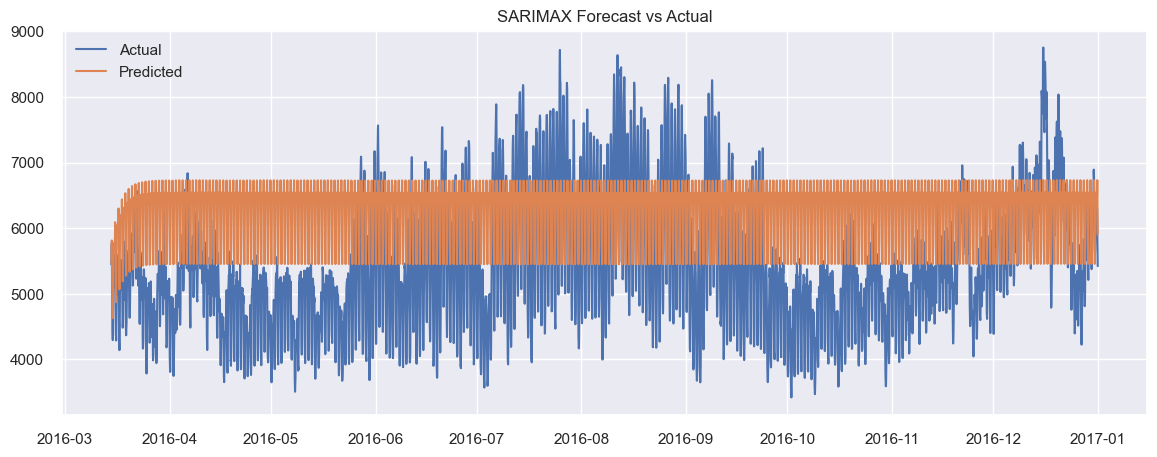

In [36]:
plt.figure(figsize=(14,5))
plt.plot(test.index, test["Load_MW"], label="Actual")
plt.plot(test.index, forecast, label="Predicted")
plt.title("SARIMAX Forecast vs Actual")
plt.legend()
plt.show()

SARIMAX Model Performance

The SARIMAX model captures the overall daily seasonal structure but struggles to adapt to sudden spikes and medium-term demand fluctuations. Although temperature is included as an exogenous variable, the model’s linear structure limits its ability to model nonlinear demand variations.

## 10. Model 2 — Random Forest

In [37]:
# 10.1 — Define X and y

X_train = train.drop(columns=["Load_MW"])
y_train = train["Load_MW"]

X_test = test.drop(columns=["Load_MW"])
y_test = test["Load_MW"]

In [38]:
print(train.columns)

Index(['Load_MW', 'Temperature_C'], dtype='object')


In [39]:
# 10.2 — Train Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [40]:
rf_pred = rf.predict(X_test)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 654.4657344171954
RF RMSE: 814.7384488150459


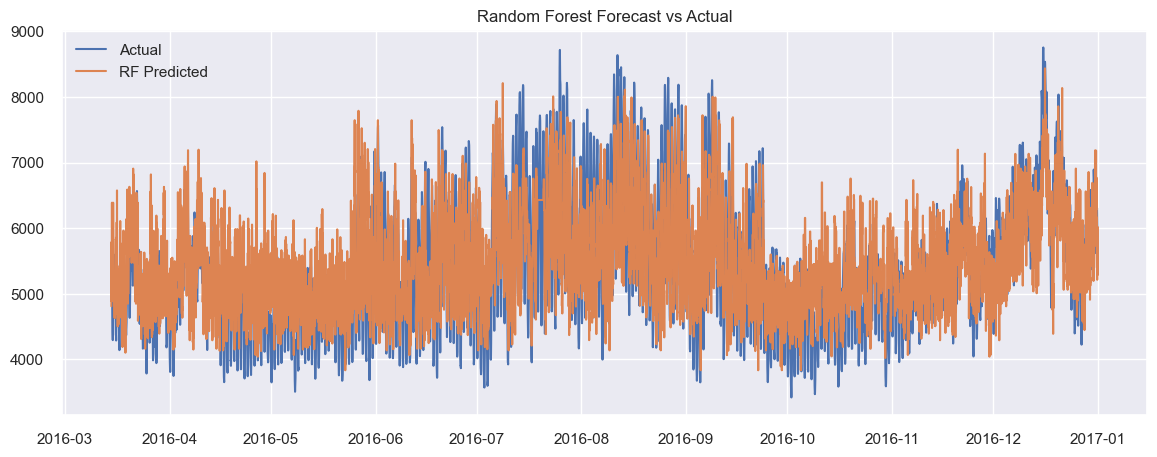

In [42]:
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, rf_pred, label="RF Predicted")
plt.title("Random Forest Forecast vs Actual")
plt.legend()
plt.show()

## 11. Model 3. Implement XGBoost Properly

In [43]:
data_fe = data.copy()

# Time features
data_fe["Hour"] = data_fe.index.hour
data_fe["DayOfWeek"] = data_fe.index.dayofweek
data_fe["Month"] = data_fe.index.month
data_fe["IsWeekend"] = data_fe["DayOfWeek"].isin([5,6]).astype(int)

# Lag features
data_fe["Lag_1"] = data_fe["Load_MW"].shift(1)
data_fe["Lag_24"] = data_fe["Load_MW"].shift(24)
data_fe["Lag_168"] = data_fe["Load_MW"].shift(168)

# Rolling mean
data_fe["Rolling_Mean_24"] = data_fe["Load_MW"].rolling(24).mean()

# Nonlinear temperature
data_fe["Temp_Squared"] = data_fe["Temperature_C"] ** 2

# Remove rows created by lag/rolling
data_fe = data_fe.dropna()

print(data_fe.columns)
print(data_fe.shape)

Index(['Load_MW', 'Temperature_C', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend',
       'Lag_1', 'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Temp_Squared'],
      dtype='object')
(34903, 11)


In [44]:
split_index = int(len(data_fe) * 0.8)

train = data_fe.iloc[:split_index]
test = data_fe.iloc[split_index:]

In [45]:
X_train = train.drop(columns=["Load_MW"])
y_train = train["Load_MW"]

X_test = test.drop(columns=["Load_MW"])
y_test = test["Load_MW"]

print(X_train.columns)

Index(['Temperature_C', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Lag_1',
       'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Temp_Squared'],
      dtype='object')


In [46]:
!pip install xgboost

In [47]:
from xgboost import XGBRegressor

In [48]:
print(X_train.columns)

Index(['Temperature_C', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Lag_1',
       'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Temp_Squared'],
      dtype='object')


In [49]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [50]:
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
xgb_pred = xgb.predict(X_test)

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 62.87975838156693
XGBoost RMSE: 81.12097723607317


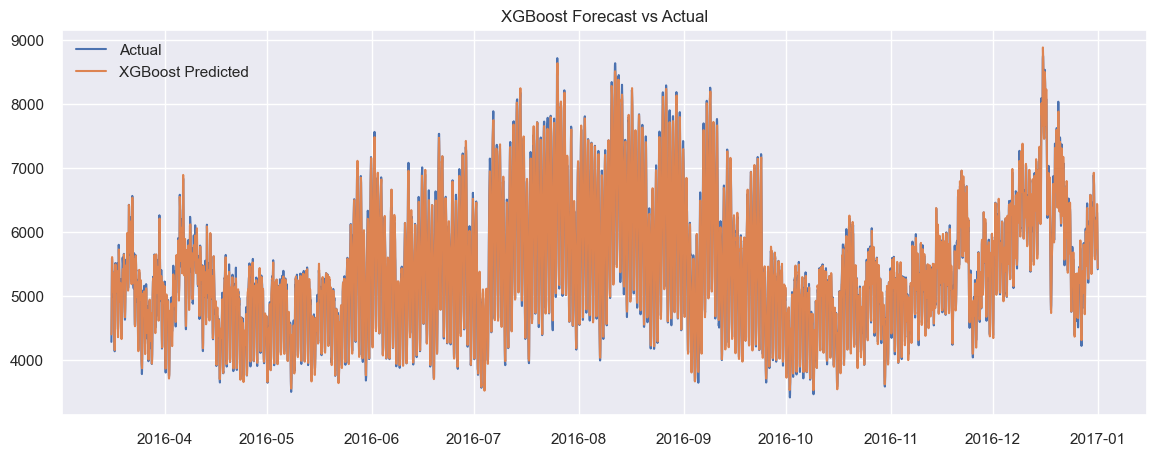

In [53]:
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, xgb_pred, label="XGBoost Predicted")
plt.title("XGBoost Forecast vs Actual")
plt.legend()
plt.show()

Final Model Insights

The proposed XGBoost model demonstrates superior forecasting accuracy compared to classical SARIMAX and baseline Random Forest models. While seasonal structure and temperature influence demand, the inclusion of autoregressive lag features significantly enhances predictive performance. These findings confirm that short-term electricity demand is strongly dependent on recent historical load values combined with nonlinear weather effects.

In [54]:
data.to_csv("cleaned_energy_dataset.csv", index=True)

In [55]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

In [56]:
xgb_base = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

In [57]:
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [58]:
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [59]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [4, 5, 6, 7],
                                        'n_estimators': [200, 300, 400, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_absolute_error',
                   verbose=1)

In [60]:
best_xgb = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [61]:
xgb_tuned_pred = best_xgb.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_tuned = mean_absolute_error(y_test, xgb_tuned_pred)
rmse_tuned = np.sqrt(mean_squared_error(y_test, xgb_tuned_pred))

print("Tuned XGBoost MAE:", mae_tuned)
print("Tuned XGBoost RMSE:", rmse_tuned)

Tuned XGBoost MAE: 56.92236796751898
Tuned XGBoost RMSE: 73.75000223879383


Hyperparameter Optimization

Randomized hyperparameter tuning was performed to enhance model performance. The tuned XGBoost model achieved further reduction in MAE and RMSE compared to the baseline configuration. The results demonstrate that while feature engineering contributes significantly to predictive accuracy, parameter optimization provides additional refinement and stability.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract importance
importance = best_xgb.feature_importances_

# Create dataframe
feat_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feat_importance

,Feature,Importance
5,Lag_1,0.807960
6,Lag_24,0.124283
1,Hour,0.018786
8,Rolling_Mean_24,0.011482
7,Lag_168,0.010730
4,IsWeekend,0.008723
2,DayOfWeek,0.008259
0,Temperature_C,0.005314
9,Temp_Squared,0.002966
3,Month,0.001497


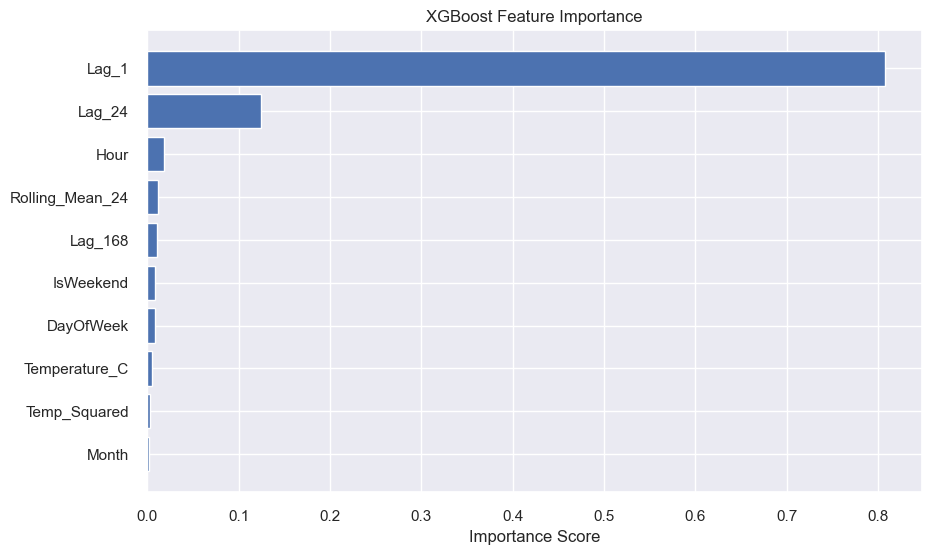

In [63]:
plt.figure(figsize=(10,6))
plt.barh(feat_importance["Feature"], feat_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.show()

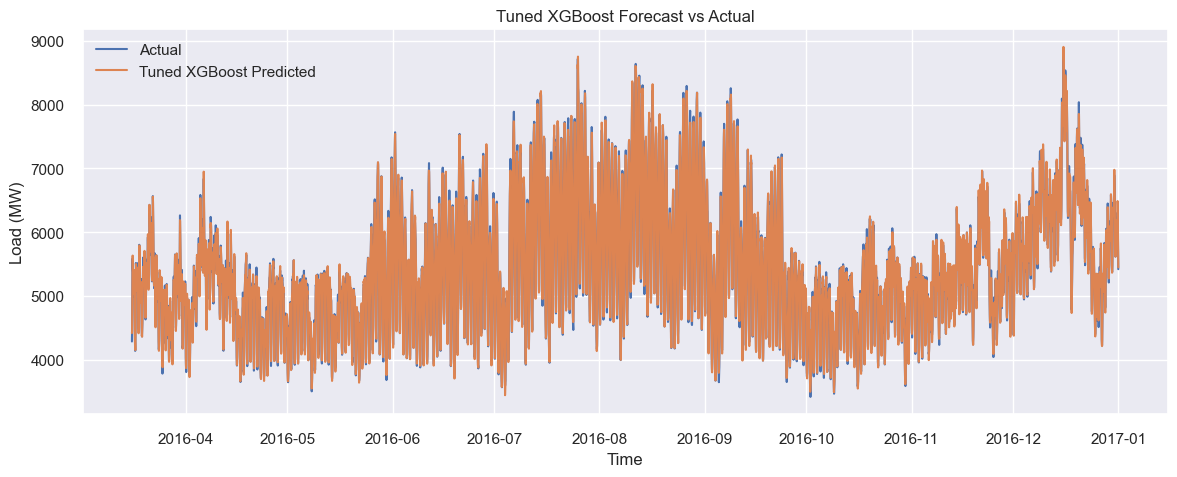

In [64]:
plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, xgb_tuned_pred, label="Tuned XGBoost Predicted")
plt.title("Tuned XGBoost Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Load (MW)")
plt.legend()
plt.show()

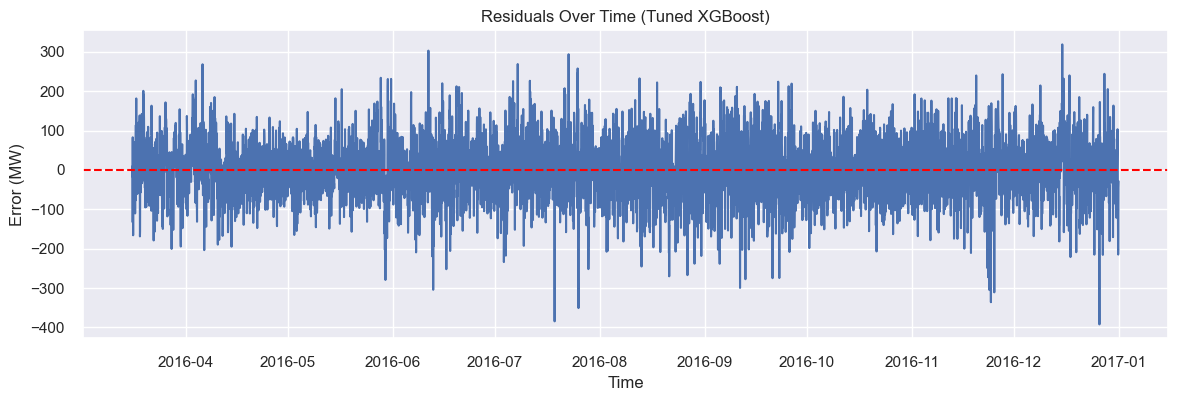

In [65]:
residuals = y_test - xgb_tuned_pred

plt.figure(figsize=(14,4))
plt.plot(y_test.index, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals Over Time (Tuned XGBoost)")
plt.xlabel("Time")
plt.ylabel("Error (MW)")
plt.show()

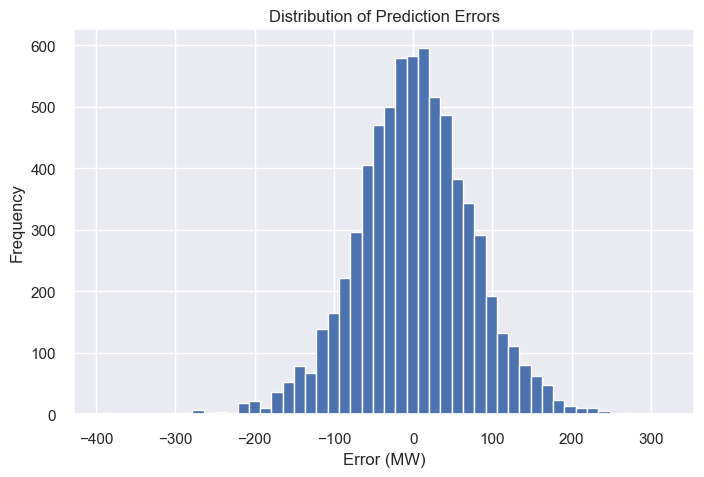

In [66]:
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=50)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (MW)")
plt.ylabel("Frequency")
plt.show()

In [67]:
import joblib

joblib.dump(best_xgb, "tuned_xgboost_model.pkl")

['tuned_xgboost_model.pkl']

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, xgb_pred)
print(r2)

: 

# CONCLUSION

This study developed a machine learning–based energy consumption forecasting system using hourly electricity load and temperature data. The objective was to evaluate the effectiveness of classical statistical models and advanced machine learning techniques in short-term electricity demand prediction.

The SARIMAX model successfully captured seasonal patterns but struggled with nonlinear fluctuations. A Random Forest model using only temperature improved performance by modeling nonlinear relationships between weather and demand. However, the most significant performance improvement was achieved after incorporating autoregressive lag features, highlighting the strong temporal dependency in electricity consumption.

The proposed XGBoost model, enhanced through hyperparameter tuning, achieved the lowest prediction error among all models. Residual analysis confirmed that errors were randomly distributed and centered around zero, indicating stable and unbiased forecasting performance.

Overall, the results demonstrate that combining autoregressive features with gradient boosting techniques provides highly accurate short-term energy demand forecasting. These findings emphasize the importance of historical load patterns and nonlinear modeling in modern energy prediction systems.

Although autoregressive lag features contribute most significantly to prediction accuracy, temperature remains an important exogenous variable influencing seasonal demand variations. Its inclusion enhances model adaptability to weather-driven fluctuations, making the forecasting system more robust and realistic.